In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, confusion_matrix, classification_report
from scipy import stats

sns.set()

pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv(r'credit_score.csv')
data

,ID,CustomerID,Month,Name,Age,SSN,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,TypeofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,CreditScore
0,0x1602,CUS0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,11.27,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,Good
1,0x1603,CUS0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,Good
2,0x1604,CUS0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7.0,NaN,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,Good
3,0x1605,CUS0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4.0,6.27,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,Good
4,0x1606,CUS0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87490,0x25fe8,CUS0x942c,March,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",20,6.0,9.50,3.0,502.38,39.323569,No,35.104023,140.581403,HighspentMediumvaluepayments,410.256158,Poor
87491,0x25fe9,CUS0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",23,7.0,11.50,3.0,502.38,34.663572,No,35.104023,60.971333,HighspentLargevaluepayments,479.866228,Poor
87492,0x25fea,CUS0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,7,2,"Auto Loan, and Student Loan",18,7.0,11.50,3.0,502.38,40.565631,No,35.104023,54.185950,HighspentMediumvaluepayments,496.651610,Poor
87493,0x25feb,CUS0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,6,5729,2,"Auto Loan, and Student Loan",27,6.0,11.50,3.0,502.38,41.255522,No,35.104023,24.028477,HighspentLargevaluepayments,516.809083,Poor


In [3]:
data.describe(include = 'all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,87495,87495,0x1602,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CustomerID,87495,12500,CUS0xd40,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,87495,8,January,10970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,78779,10139,Langep,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,87495.0,NaN,NaN,NaN,110.467364,686.549658,-500.0,24.0,33.0,42.0,8698.0
SSN,87495,12501,#F%$D@*&8,4857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,81317,15,Lawyer,5762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnnualIncome,87495.0,NaN,NaN,NaN,180240.414719,1455211.725969,7005.93,19433.48,37579.75,72886.08,24198062.0
MonthlyInhandSalary,74319.0,NaN,NaN,NaN,4193.181285,3179.195651,303.645417,1626.677917,3095.905,5967.93,15204.63333
NumBankAccounts,87495.0,NaN,NaN,NaN,17.112646,117.428586,-1.0,3.0,6.0,7.0,1798.0


In [4]:
data.drop(['ID', 'CustomerID', 'Name', 'SSN', 'TypeofLoan'], axis=1, inplace = True)

data.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Month,87495,8,January,10970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,87495.0,NaN,NaN,NaN,110.467364,686.549658,-500.0,24.0,33.0,42.0,8698.0
Occupation,81317,15,Lawyer,5762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AnnualIncome,87495.0,NaN,NaN,NaN,180240.414719,1455211.725969,7005.93,19433.48,37579.75,72886.08,24198062.0
MonthlyInhandSalary,74319.0,NaN,NaN,NaN,4193.181285,3179.195651,303.645417,1626.677917,3095.905,5967.93,15204.63333
NumBankAccounts,87495.0,NaN,NaN,NaN,17.112646,117.428586,-1.0,3.0,6.0,7.0,1798.0
NumCreditCard,87495.0,NaN,NaN,NaN,22.664792,129.806747,0.0,4.0,5.0,7.0,1499.0
InterestRate,87495.0,NaN,NaN,NaN,73.050871,467.727237,1.0,8.0,13.0,20.0,5797.0
NumofLoan,87495.0,NaN,NaN,NaN,7.019841,60.352339,0.0,1.0,3.0,5.0,1495.0
Delayfromduedate,87495.0,NaN,NaN,NaN,21.060403,14.864558,-5.0,10.0,18.0,28.0,67.0


In [5]:
data.isnull().sum()

Month                         0
Age                           0
Occupation                 6178
AnnualIncome                  0
MonthlyInhandSalary       13176
NumBankAccounts               0
NumCreditCard                 0
InterestRate                  0
NumofLoan                     0
Delayfromduedate              0
NumofDelayedPayment        6095
ChangedCreditLimit         1841
NumCreditInquiries         1706
OutstandingDebt               0
CreditUtilizationRatio        0
PaymentofMinAmount            0
TotalEMIpermonth              0
Amountinvestedmonthly      7709
PaymentBehaviour              0
MonthlyBalance             1058
CreditScore                   0
dtype: int64

In [6]:
for i in data.columns:
    if pd.api.types.is_numeric_dtype(data[i]):
        data[i] = data[i].fillna(value=data[i].mean())
    else:
        data[i] = data[i].fillna(value=data[i].mode()[0])

data.isnull().sum()

Month                     0
Age                       0
Occupation                0
AnnualIncome              0
MonthlyInhandSalary       0
NumBankAccounts           0
NumCreditCard             0
InterestRate              0
NumofLoan                 0
Delayfromduedate          0
NumofDelayedPayment       0
ChangedCreditLimit        0
NumCreditInquiries        0
OutstandingDebt           0
CreditUtilizationRatio    0
PaymentofMinAmount        0
TotalEMIpermonth          0
Amountinvestedmonthly     0
PaymentBehaviour          0
MonthlyBalance            0
CreditScore               0
dtype: int64

In [7]:
data['score'] = np.where(data['CreditScore']=='Poor',1,0)
data.drop('CreditScore', axis=1, inplace=True)
data.columns

Index(['Month', 'Age', 'Occupation', 'AnnualIncome', 'MonthlyInhandSalary',
       'NumBankAccounts', 'NumCreditCard', 'InterestRate', 'NumofLoan',
       'Delayfromduedate', 'NumofDelayedPayment', 'ChangedCreditLimit',
       'NumCreditInquiries', 'OutstandingDebt', 'CreditUtilizationRatio',
       'PaymentofMinAmount', 'TotalEMIpermonth', 'Amountinvestedmonthly',
       'PaymentBehaviour', 'MonthlyBalance', 'score'],
      dtype='str')

In [8]:
data.score.value_counts()

score
0    62145
1    25350
Name: count, dtype: int64

In [11]:
woe_maps = {}
bin_edges = {}

for var in data.columns:
    if var == 'score':
        continue  

    if pd.api.types.is_numeric_dtype(data[var]):
        
        q1 = data[var].quantile(0.25)
        q2 = data[var].quantile(0.5)
        q3 = data[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        if var in ['OutstandingDebt',	'InterestRate',	'NumCreditInquiries',	'Delayfromduedate']:
            bin_edges[var] = ranges
        data['category_' + var] = pd.cut(data[var], bins=ranges, duplicates='drop')

        grouped = data.groupby(['category_' + var, 'score'])['score'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data = data.merge(grouped[['category_' + var, var + '_woe']], how='left', on='category_' + var)
        
        if var in ['OutstandingDebt',	'InterestRate',	'NumCreditInquiries',	'Delayfromduedate']:
            woe_maps[var] = grouped[['category_' + var, var + '_woe']]

    else:

        grouped = data.groupby([var, 'score'])['score'].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data = data.merge(grouped[[var, var + '_woe']], how='left', on=var)

In [12]:
data

,Month,Age,Occupation,AnnualIncome,MonthlyInhandSalary,NumBankAccounts,NumCreditCard,InterestRate,NumofLoan,Delayfromduedate,NumofDelayedPayment,ChangedCreditLimit,NumCreditInquiries,OutstandingDebt,CreditUtilizationRatio,PaymentofMinAmount,TotalEMIpermonth,Amountinvestedmonthly,PaymentBehaviour,MonthlyBalance,score,Month_woe,category_Age,Age_woe,Occupation_woe,category_AnnualIncome,AnnualIncome_woe,category_MonthlyInhandSalary,MonthlyInhandSalary_woe,category_NumBankAccounts,NumBankAccounts_woe,category_NumCreditCard,NumCreditCard_woe,category_InterestRate,InterestRate_woe,category_NumofLoan,NumofLoan_woe,category_Delayfromduedate,Delayfromduedate_woe,category_NumofDelayedPayment,NumofDelayedPayment_woe,category_ChangedCreditLimit,ChangedCreditLimit_woe,category_NumCreditInquiries,NumCreditInquiries_woe,category_OutstandingDebt,OutstandingDebt_woe,category_CreditUtilizationRatio,CreditUtilizationRatio_woe,PaymentofMinAmount_woe,category_TotalEMIpermonth,TotalEMIpermonth_woe,category_Amountinvestedmonthly,Amountinvestedmonthly_woe,PaymentBehaviour_woe,category_MonthlyBalance,MonthlyBalance_woe
0,January,23,Scientist,19114.12,1824.843333,3,4,3,4,3,7.000000,11.270000,4.0,809.98,26.822620,No,49.574949,80.415295,HighspentSmallvaluepayments,312.494089,0,0.013036,"(-inf, 24.0]",-0.221890,-0.080783,"(-inf, 19433.48]",-0.544667,"(1792.52, 3860.632]",0.163879,"(-inf, 3.0]",0.775176,"(-inf, 4.0]",1.077752,"(-inf, 8.0]",0.963156,"(3.0, 5.0]",-0.105828,"(-inf, 10.0]",1.050763,"(-inf, 9.0]",0.651120,"(9.56, 14.64]",0.131787,"(3.0, 6.0]",0.558452,"(566.4, 1166.23]",1.209568,"(-inf, 28.059]",-0.085018,0.97376,"(30.453, 69.286]",-0.143113,"(76.962, 143.313]",-0.124014,0.087011,"(270.918, 338.591]",-0.237030
1,February,23,Scientist,19114.12,4193.181285,3,4,3,4,-1,30.904324,11.270000,4.0,809.98,31.944960,No,49.574949,118.280222,LowspentLargevaluepayments,284.629163,0,0.031453,"(-inf, 24.0]",-0.221890,-0.080783,"(-inf, 19433.48]",-0.544667,"(3860.632, 5376.237]",-0.157230,"(-inf, 3.0]",0.775176,"(-inf, 4.0]",1.077752,"(-inf, 8.0]",0.963156,"(3.0, 5.0]",-0.105828,"(-inf, 10.0]",1.050763,"(19.0, inf]",-0.642278,"(9.56, 14.64]",0.131787,"(3.0, 6.0]",0.558452,"(566.4, 1166.23]",1.209568,"(28.059, 32.322]",-0.013608,0.97376,"(30.453, 69.286]",-0.143113,"(76.962, 143.313]",-0.124014,0.057730,"(270.918, 338.591]",-0.237030
2,March,-500,Scientist,19114.12,4193.181285,3,4,3,4,3,7.000000,10.385851,4.0,809.98,28.609352,No,49.574949,81.699521,LowspentMediumvaluepayments,331.209863,0,0.021323,"(-inf, 24.0]",-0.221890,-0.080783,"(-inf, 19433.48]",-0.544667,"(3860.632, 5376.237]",-0.157230,"(-inf, 3.0]",0.775176,"(-inf, 4.0]",1.077752,"(-inf, 8.0]",0.963156,"(3.0, 5.0]",-0.105828,"(-inf, 10.0]",1.050763,"(-inf, 9.0]",0.651120,"(9.56, 14.64]",0.131787,"(3.0, 6.0]",0.558452,"(566.4, 1166.23]",1.209568,"(28.059, 32.322]",-0.013608,0.97376,"(30.453, 69.286]",-0.143113,"(76.962, 143.313]",-0.124014,-0.070569,"(270.918, 338.591]",-0.237030
3,April,23,Scientist,19114.12,4193.181285,3,4,3,4,5,4.000000,6.270000,4.0,809.98,31.377862,No,49.574949,199.458074,LowspentSmallvaluepayments,223.451310,0,-0.017560,"(-inf, 24.0]",-0.221890,-0.080783,"(-inf, 19433.48]",-0.544667,"(3860.632, 5376.237]",-0.157230,"(-inf, 3.0]",0.775176,"(-inf, 4.0]",1.077752,"(-inf, 8.0]",0.963156,"(3.0, 5.0]",-0.105828,"(-inf, 10.0]",1.050763,"(-inf, 9.0]",0.651120,"(5.425, 9.56]",0.039621,"(3.0, 6.0]",0.558452,"(566.4, 1166.23]",1.209568,"(28.059, 32.322]",-0.013608,0.97376,"(30.453, 69.286]",-0.143113,"(143.313, 219.931]",0.015442,-0.315796,"(-inf, 270.918]",-0.489969
4,May,23,Scientist,19114.12,1824.843333,3,4,3,4,6,30.904324,11.270000,4.0,809.98,24.797347,No,49.574949,41.420153,HighspentMediumvaluepayments,341.489231,0,-0.019930,"(-inf, 24.0]",-0.221890,-0.080783,"(-inf, 19433.48]",-0.544667,"(1792.52, 3860.632]",0.163879,"(-inf, 3.0]",0.775176,"(-inf, 4.0]",1.077752,"(-inf, 8.0]",0.963156,"(3.0, 5.0]",-0.105828,"(-inf, 10.0]",1.050763,"(19.0, inf]",-0.642278,"(9.56, 14.64]",0.131787,"(3.0, 6.0

In [14]:
for i in data.columns:
    
    if data[i].dtype in ['int64', 'float64']:
        
        kstest_statistic, kstest_p_value = stats.kstest(data[i], 'norm')
        
        print(f'Column: {i}')
        print(f'Kolmogorov-Smirnov Test:')
        print(f'Test Statistic: {kstest_statistic}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: Age
Kolmogorov-Smirnov Test:
Test Statistic: 0.9904794559689125
p-value: 0.0
Data does not look normally distributed

Column: AnnualIncome
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: MonthlyInhandSalary
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: NumBankAccounts
Kolmogorov-Smirnov Test:
Test Statistic: 0.889153405396812
p-value: 0.0
Data does not look normally distributed

Column: NumCreditCard
Kolmogorov-Smirnov Test:
Test Statistic: 0.9558429305125329
p-value: 0.0
Data does not look normally distributed

Column: InterestRate
Kolmogorov-Smirnov Test:
Test Statistic: 0.9505969164545867
p-value: 0.0
Data does not look normally distributed

Column: NumofLoan
Kolmogorov-Smirnov Test:
Test Statistic: 0.724195407796949
p-value: 0.0
Data does not look normally distributed

Column: Delayfromduedate
Kolmogorov-Smirnov Test:
Test Statistic: 0.953961834067347
p-va

In [16]:
def target_correlation(data, target, threshold=0.1):
    
    woe_features = data.filter(regex=r'_woe$', axis=1)
    woe_features[target] = data[target]
    
    corr_matrix = woe_features.corr(method='spearman', numeric_only=True)
    
    target_corr = corr_matrix[target]
    variables_explaining_target = (
        target_corr[abs(target_corr) > threshold]
        .drop(target, errors='ignore')
        .index
        .tolist()
    )
    
    result_explaining_target = (
        pd.DataFrame({
            'Variable': variables_explaining_target,
            'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]
        })
        .reset_index(drop=True)
    )
    
    return result_explaining_target


target_result = target_correlation(data, 'score')

target_result

,Variable,Correlation with Target
0,Age_woe,-0.102439
1,AnnualIncome_woe,-0.199462
2,MonthlyInhandSalary_woe,-0.174459
3,NumBankAccounts_woe,-0.262026
4,NumCreditCard_woe,-0.314837
5,InterestRate_woe,-0.406848
6,NumofLoan_woe,-0.287626
7,Delayfromduedate_woe,-0.338427
8,NumofDelayedPayment_woe,-0.222047
9,NumCreditInquiries_woe,-0.360778


In [17]:
def intercorrelation(data, target, threshold=0.7):
    
    woe_features = data.filter(regex=r'_woe$', axis=1).copy()
    
    corr_matrix = woe_features.corr(method='spearman', numeric_only=True)
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)


intercorrelated_result = intercorrelation(data, 'score')
intercorrelated_result

,Variable 1,Variable 2,Correlation
0,AnnualIncome_woe,MonthlyInhandSalary_woe,0.729928


In [19]:
inputs = data[target_result['Variable']]

dependant = data['score']
dependant

0        0
1        0
2        0
3        0
4        0
        ..
87490    1
87491    1
87492    1
87493    1
87494    0
Name: score, Length: 87495, dtype: int64

# Modeling

In [21]:
X_train, X_test, y_train, y_test = train_test_split(inputs, dependant, test_size=0.3, random_state=7)

In [23]:
def evaluate(model, X_train, y_train, X_test, y_test):
    
    '''Predictions and probabilities for the training set'''
    
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    '''Predictions and probabilities for the test set'''
    
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    '''Calculate metrics for the training set''' 
    
    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)

    '''Calculate metrics for the test set'''
    
    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    confusion_matrix = metrics.confusion_matrix(y_test, y_test_pred)
    
    return results , confusion_matrix

In [25]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
results = evaluate(clf, X_train, y_train, X_test, y_test)
results

(  Dataset       Gini  Precision    Recall
 0   Train  59.339325   0.635066  0.564951
 1    Test  58.906244   0.628893  0.569518,
 array([[16159,  2538],
        [ 3251,  4301]]))

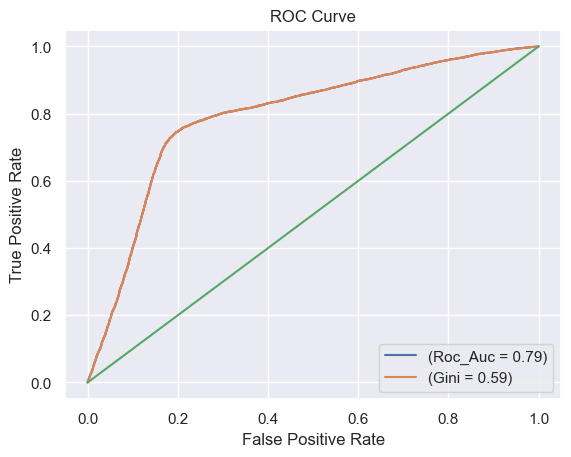

In [29]:
y_prob = clf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
gini = (2*roc_auc_score(y_test, y_prob))-1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()

plt.plot(fpr, tpr, label='(Roc_Auc = %0.2f)' % roc_auc)
plt.plot(fpr, tpr, label='(Gini = %0.2f)' % gini)
plt.plot([0, 1], [0, 1])
plt.xlim()
plt.ylim()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')
plt.show()

In [31]:
variables = []
train_gini_scores = []
test_gini_scores = []


for i in X_train.columns:
    X_train_single_var = X_train[[i]]
    X_test_single_var = X_test[[i]]

    
    clf.fit(X_train_single_var, y_train)
    
    y_pred_train_single_var = clf.predict_proba(X_train_single_var)[:, 1]

    train_roc = roc_auc_score(y_train, y_pred_train_single_var)
    train_gini = 2 * train_roc - 1

    
    y_pred_test_single_var = clf.predict_proba(X_test_single_var)[:, 1]

    test_roc = roc_auc_score(y_test, y_pred_test_single_var)
    test_gini = 2 * test_roc - 1


    variables.append(i)
    train_gini_scores.append(train_gini)
    test_gini_scores.append(test_gini)


results_df = pd.DataFrame({
                            'Variable': variables,
                            'Train Gini': train_gini_scores,
                            'Test Gini': test_gini_scores
                        })

results_df_sorted = results_df.sort_values(by='Test Gini', ascending=False)

pd.options.display.float_format = '{:.4f}'.format

results_df_sorted

,Variable,Train Gini,Test Gini
10,OutstandingDebt_woe,0.5148,0.5131
5,InterestRate_woe,0.4984,0.5054
9,NumCreditInquiries_woe,0.4413,0.4485
7,Delayfromduedate_woe,0.4182,0.4140
4,NumCreditCard_woe,0.3862,0.3806
6,NumofLoan_woe,0.3513,0.3598
3,NumBankAccounts_woe,0.3193,0.3184
11,PaymentofMinAmount_woe,0.3027,0.3008
8,NumofDelayedPayment_woe,0.2727,0.2747
13,MonthlyBalance_woe,0.2347,0.2421


In [32]:
data.drop(['AnnualIncome_woe', 'MonthlyInhandSalary_woe'], axis=1, inplace=True)

In [33]:
filtered_df = results_df_sorted[
    (results_df_sorted['Test Gini'] > 0.40) &
    (abs(results_df_sorted['Train Gini'] - results_df_sorted['Test Gini']) <= 0.05)
]

filtered_df

,Variable,Train Gini,Test Gini
10,OutstandingDebt_woe,0.5148,0.5131
5,InterestRate_woe,0.4984,0.5054
9,NumCreditInquiries_woe,0.4413,0.4485
7,Delayfromduedate_woe,0.4182,0.4140


In [34]:
inputs_uni = data[filtered_df["Variable"]]

dependant = data['score']

In [35]:
X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(inputs_uni, dependant, test_size=0.3, random_state=7)

In [36]:
clf_uni = LogisticRegression()
clf_uni.fit(X_train_uni, y_train_uni)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
result_uni = evaluate(clf_uni, X_train_uni, y_train_uni, X_test_uni, y_test_uni)

result_uni

(  Dataset    Gini  Precision  Recall
 0   Train 56.2635     0.6307  0.5821
 1    Test 56.2344     0.6251  0.5833,
 array([[16055,  2642],
        [ 3147,  4405]]))

In [39]:
data_deploy = pd.read_excel('prod_data_with_woe.xlsx')
data_deploy

,Unnamed: 0,Age_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,NumCreditInquiries_woe,OutstandingDebt_woe,MonthlyBalance_woe,PaymentofMinAmount_woe,PaymentBehaviour_woe
0,66072,-0.1156,0.6777,0.6042,0.3233,0.0409,-0.0280,-0.1058,-1.0948,0.3325,1.1029,-0.3521,0.6836,0.9738,0.3910
1,6931,-0.1156,0.2314,-0.4757,0.3233,0.0409,-0.0280,0.3208,-0.1009,-0.2813,0.5585,-0.3521,-0.2370,-0.4725,-0.0706
2,3064,-0.0589,-0.1881,0.1639,0.7752,0.0409,-1.3762,0.9065,1.0508,0.6511,0.5585,-0.3521,0.6836,0.9738,0.1827
3,9134,-0.2219,0.2314,0.1639,-0.7832,-1.2249,-0.0280,0.3208,0.4968,0.3325,-1.0683,-1.2232,-0.4900,-0.4725,-0.3158
4,47254,-0.1156,-0.1881,-0.1572,-0.7832,0.0409,-1.3762,-0.1058,-1.0948,-0.6423,-0.4761,-1.2232,0.6836,-0.0110,0.1827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,52892,-0.2219,0.2314,-0.1572,-0.3802,-1.2249,-0.0280,-0.1058,-1.0948,-0.6423,-1.0683,-1.2232,0.2145,-0.4725,-0.3158
796,53553,0.4878,-0.1881,0.1639,0.3233,-0.0785,0.9632,0.3208,1.0508,-0.2813,1.1029,-0.3521,0.2145,-0.0110,0.3910
797,39282,-0.2219,-0.1881,-0.1572,-0.7832,-0.0785,-1.3762,-0.9635,-1.0948,-0.6423,-0.4761,-1.2232,-0.2370,-0.4725,-0.0034
798,53283,-0.0589,-0.5447,-0.4757,0.3233,-1.2249,-0.0280,0.9065,-0.1009,-0.2813,-0.4761,-1.2232,-0.4900,-0.0110,-0.3158


In [40]:
data_deploy = data_deploy.rename(columns={'Unnamed: 0': 'CustomerID'})

In [41]:
inputs_deploy = data_deploy[filtered_df["Variable"]]
inputs_deploy

,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe
0,-0.3521,-0.0280,1.1029,-1.0948
1,-0.3521,-0.0280,0.5585,-0.1009
2,-0.3521,-1.3762,0.5585,1.0508
3,-1.2232,-0.0280,-1.0683,0.4968
4,-1.2232,-1.3762,-0.4761,-1.0948
...,...,...,...,...
795,-1.2232,-0.0280,-1.0683,-1.0948
796,-0.3521,0.9632,1.1029,1.0508
797,-1.2232,-1.3762,-0.4761,-1.0948
798,-1.2232,-0.0280,-0.4761,-0.1009


In [42]:
data_deploy['Score'] = clf_uni.predict_proba(inputs_deploy)[:,1]
data_deploy

,CustomerID,Age_woe,AnnualIncome_woe,MonthlyInhandSalary_woe,NumBankAccounts_woe,NumCreditCard_woe,InterestRate_woe,NumofLoan_woe,Delayfromduedate_woe,NumofDelayedPayment_woe,NumCreditInquiries_woe,OutstandingDebt_woe,MonthlyBalance_woe,PaymentofMinAmount_woe,PaymentBehaviour_woe,Score
0,66072,-0.1156,0.6777,0.6042,0.3233,0.0409,-0.0280,-0.1058,-1.0948,0.3325,1.1029,-0.3521,0.6836,0.9738,0.3910,0.3387
1,6931,-0.1156,0.2314,-0.4757,0.3233,0.0409,-0.0280,0.3208,-0.1009,-0.2813,0.5585,-0.3521,-0.2370,-0.4725,-0.0706,0.3094
2,3064,-0.0589,-0.1881,0.1639,0.7752,0.0409,-1.3762,0.9065,1.0508,0.6511,0.5585,-0.3521,0.6836,0.9738,0.1827,0.3672
3,9134,-0.2219,0.2314,0.1639,-0.7832,-1.2249,-0.0280,0.3208,0.4968,0.3325,-1.0683,-1.2232,-0.4900,-0.4725,-0.3158,0.4736
4,47254,-0.1156,-0.1881,-0.1572,-0.7832,0.0409,-1.3762,-0.1058,-1.0948,-0.6423,-0.4761,-1.2232,0.6836,-0.0110,0.1827,0.6803
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,52892,-0.2219,0.2314,-0.1572,-0.3802,-1.2249,-0.0280,-0.1058,-1.0948,-0.6423,-1.0683,-1.2232,0.2145,-0.4725,-0.3158,0.5821
796,53553,0.4878,-0.1881,0.1639,0.3233,-0.0785,0.9632,0.3208,1.0508,-0.2813,1.1029,-0.3521,0.2145,-0.0110,0.3910,0.1569
797,39282,-0.2219,-0.1881,-0.1572,-0.7832,-0.0785,-1.3762,-0.9635,-1.0948,-0.6423,-0.4761,-1.2232,-0.2370,-0.4725,-0.0034,0.6803
798,53283,-0.0589,-0.5447,-0.4757,0.3233,-1.2249,-0.0280,0.9065,-0.1009,-0.2813,-0.4761,-1.2232,-0.4900,-0.0110,-0.3158,0.4768


### Version 2

In [43]:
inputs_uni.columns

Index(['OutstandingDebt_woe', 'InterestRate_woe', 'NumCreditInquiries_woe',
       'Delayfromduedate_woe'],
      dtype='str')

In [44]:
data_deploy = data_deploy[['CustomerID','OutstandingDebt_woe', 'InterestRate_woe', 'NumCreditInquiries_woe',
       'Delayfromduedate_woe']]
data_deploy['Score_V2'] = clf_uni.predict_proba(data_deploy.iloc[:,1:])[:,1]

data_deploy

,CustomerID,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe,Score_V2
0,66072,-0.3521,-0.0280,1.1029,-1.0948,0.3387
1,6931,-0.3521,-0.0280,0.5585,-0.1009,0.3094
2,3064,-0.3521,-1.3762,0.5585,1.0508,0.3672
3,9134,-1.2232,-0.0280,-1.0683,0.4968,0.4736
4,47254,-1.2232,-1.3762,-0.4761,-1.0948,0.6803
...,...,...,...,...,...,...
795,52892,-1.2232,-0.0280,-1.0683,-1.0948,0.5821
796,53553,-0.3521,0.9632,1.1029,1.0508,0.1569
797,39282,-1.2232,-1.3762,-0.4761,-1.0948,0.6803
798,53283,-1.2232,-0.0280,-0.4761,-0.1009,0.4768


# Deployment with real values

In [46]:
data_real = pd.read_excel('test_data_real_values.xlsx')

data_real

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID
0,632.9300,17,0,20,53115
1,3259.1700,24,11,53,35538
2,2313.6000,22,11,55,15150
3,556.8500,16,8,23,65145
4,1115.0600,6,3,16,23224
...,...,...,...,...,...
995,1360.3100,11,8,6,86109
996,1213.2600,11,6,22,62411
997,1509.7200,27,11,18,5554
998,356.6900,18,9,25,70288


In [47]:
data_real.describe()

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,1417.0545,15.3430,6.4160,20.9000,43764.8210
std,1109.4079,9.3965,4.3416,14.4377,25329.9021
min,0.7700,1.0000,0.0000,-3.0000,52.0000
25%,572.3425,8.0000,3.0000,10.0000,21709.7500
50%,1153.7700,14.0000,6.0000,18.0000,44880.0000
75%,1941.2475,22.0000,9.0000,28.0000,65438.2500
max,4022.8500,38.0000,18.0000,55.0000,87424.0000


In [48]:
for var in bin_edges.keys():

    
    data_real['category_' + var] = pd.cut(
        data_real[var],
        bins=bin_edges[var]
    )

    
    mapping = dict(zip(
        woe_maps[var]['category_' + var],
        woe_maps[var][var + '_woe']
    ))

    
    data_real[var + '_woe'] = data_real['category_' + var].map(mapping) 

In [49]:
data_real

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID,category_InterestRate,InterestRate_woe,category_Delayfromduedate,Delayfromduedate_woe,category_NumCreditInquiries,NumCreditInquiries_woe,category_OutstandingDebt,OutstandingDebt_woe
0,632.9300,17,0,20,53115,"(13.0, 20.0]",-0.0280,"(18.0, 28.0]",-0.1009,"(-inf, 3.0]",1.1029,"(566.4, 1166.23]",1.2096
1,3259.1700,24,11,53,35538,"(20.0, inf]",-1.3762,"(28.0, inf]",-1.0948,"(9.0, inf]",-1.0683,"(1948.98, inf]",-1.2232
2,2313.6000,22,11,55,15150,"(20.0, inf]",-1.3762,"(28.0, inf]",-1.0948,"(9.0, inf]",-1.0683,"(1948.98, inf]",-1.2232
3,556.8500,16,8,23,65145,"(13.0, 20.0]",-0.0280,"(18.0, 28.0]",-0.1009,"(6.0, 9.0]",-0.4761,"(-inf, 566.4]",1.2719
4,1115.0600,6,3,16,23224,"(-inf, 8.0]",0.9632,"(10.0, 18.0]",0.4968,"(-inf, 3.0]",1.1029,"(566.4, 1166.23]",1.2096
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1360.3100,11,8,6,86109,"(8.0, 13.0]",1.1494,"(-inf, 10.0]",1.0508,"(6.0, 9.0]",-0.4761,"(1166.23, 1948.98]",-0.3521
996,1213.2600,11,6,22,62411,"(8.0, 13.0]",1.1494,"(18.0, 28.0]",-0.1009,"(3.0, 6.0]",0.5585,"(1166.23, 1948.98]",-0.3521
997,1509.7200,27,11,18,5554,"(20.0, inf]",-1.3762,"(10.0, 18.0]",0.4968,"(9.0, inf]",-1.0683,"(1166.23, 1948.98]",-0.3521
998,356.6900,18,9,25,70288,"(13.0, 20.0]",-0.0280,"(18.0, 28.0]",-0.1009,"(6.0, 9.0]",-0.4761,"(-inf, 566.4]",1.2719


In [50]:
inputs_real = data_real[filtered_df["Variable"]]
inputs_real

,OutstandingDebt_woe,InterestRate_woe,NumCreditInquiries_woe,Delayfromduedate_woe
0,1.2096,-0.0280,1.1029,-0.1009
1,-1.2232,-1.3762,-1.0683,-1.0948
2,-1.2232,-1.3762,-1.0683,-1.0948
3,1.2719,-0.0280,-0.4761,-0.1009
4,1.2096,0.9632,1.1029,0.4968
...,...,...,...,...
995,-0.3521,1.1494,-0.4761,1.0508
996,-0.3521,1.1494,0.5585,-0.1009
997,-0.3521,-1.3762,-1.0683,0.4968
998,1.2719,-0.0280,-0.4761,-0.1009


In [51]:
data_real['PD'] = clf_uni.predict_proba(inputs_real)[:,1]
data_real

,OutstandingDebt,InterestRate,NumCreditInquiries,Delayfromduedate,CustomerID,category_InterestRate,InterestRate_woe,category_Delayfromduedate,Delayfromduedate_woe,category_NumCreditInquiries,NumCreditInquiries_woe,category_OutstandingDebt,OutstandingDebt_woe,PD
0,632.9300,17,0,20,53115,"(13.0, 20.0]",-0.0280,"(18.0, 28.0]",-0.1009,"(-inf, 3.0]",1.1029,"(566.4, 1166.23]",1.2096,0.1492
1,3259.1700,24,11,53,35538,"(20.0, inf]",-1.3762,"(28.0, inf]",-1.0948,"(9.0, inf]",-1.0683,"(1948.98, inf]",-1.2232,0.7123
2,2313.6000,22,11,55,15150,"(20.0, inf]",-1.3762,"(28.0, inf]",-1.0948,"(9.0, inf]",-1.0683,"(1948.98, inf]",-1.2232,0.7123
3,556.8500,16,8,23,65145,"(13.0, 20.0]",-0.0280,"(18.0, 28.0]",-0.1009,"(6.0, 9.0]",-0.4761,"(-inf, 566.4]",1.2719,0.2028
4,1115.0600,6,3,16,23224,"(-inf, 8.0]",0.9632,"(10.0, 18.0]",0.4968,"(-inf, 3.0]",1.1029,"(566.4, 1166.23]",1.2096,0.0888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1360.3100,11,8,6,86109,"(8.0, 13.0]",1.1494,"(-inf, 10.0]",1.0508,"(6.0, 9.0]",-0.4761,"(1166.23, 1948.98]",-0.3521,0.2047
996,1213.2600,11,6,22,62411,"(8.0, 13.0]",1.1494,"(18.0, 28.0]",-0.1009,"(3.0, 6.0]",0.5585,"(1166.23, 1948.98]",-0.3521,0.2133
997,1509.7200,27,11,18,5554,"(20.0, inf]",-1.3762,"(10.0, 18.0]",0.4968,"(9.0, inf]",-1.0683,"(1166.23, 1948.98]",-0.3521,0.5060
998,356.6900,18,9,25,70288,"(13.0, 20.0]",-0.0280,"(18.0, 28.0]",-0.1009,"(6.0, 9.0]",-0.4761,"(-inf, 566.4]",1.2719,0.2028
